# Assignment 1 Task 3

In [226]:
# Do not install the unrelated `commpy` package here; it breaks
# `from commpy.channelcoding import ...` in this environment.
%pip install -q scikit-commpy


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Imports

In [227]:

import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.signal import butter, freqz, filtfilt
from commpy.channelcoding import Trellis, conv_encode, viterbi_decode
from numpy.lib.stride_tricks import sliding_window_view


In [228]:
# matlab uses deprecated method to generate this
# thus it needs to be hardcoded to work in python
def get_P():
    return np.array([
        1, -1, -1, 1, -1, -1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1, 1, 1, -1, 1, -1, -1, 1, -1, 1, 1, 1, -1, -1, 1, -1, 1, -1, 1, -1, 1, 1, -1, 1, 1, -1, 1, 1, 1, -1, -1, 1, 1, 1, 1, 1, -1, 1, 1, 1, -1, 1, 1, -1, 1, 1, -1, 1, -1
    ])

In [229]:
# Load signal
data = scipy.io.loadmat('Signals_task3/signal3.mat')
r = data['R'].flatten()

# System parameters
fs = 44100
fc = 10000
Nsc = 128
Ncp = 20
Tsym = 58 * 10**-3



### Demodulation

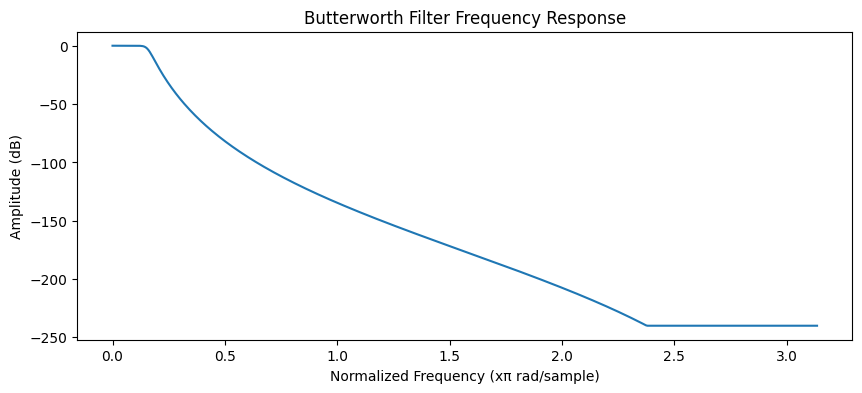

In [230]:

n = np.arange(len(r))
r_I =  2 * r * np.cos(2 * np.pi * fc * n / fs)
r_Q = -2 * r * np.sin(2 * np.pi * fc * n / fs)

b, a = butter(8, 0.05)
r_I_filt = filtfilt(b, a, r_I)
r_Q_filt = filtfilt(b, a, r_Q)

w, h = freqz(b, a)
plt.plot(w, 20 * np.log10(np.maximum(np.abs(h), 1e-12)))
plt.title("Butterworth Filter Frequency Response")
plt.xlabel("Normalized Frequency (xπ rad/sample)")
plt.ylabel("Amplitude (dB)")
plt.grid()
plt.show()


## AD conversion and down sampling

In [231]:

D = fs * Tsym / Nsc
sample_idx = np.arange(0, len(r_I_filt), D)

r_I_down = np.interp(sample_idx, np.arange(len(r_I_filt)), r_I_filt)
r_Q_down = np.interp(sample_idx, np.arange(len(r_Q_filt)), r_Q_filt)
r_bb = r_I_down + 1j * r_Q_down

print(f"D={D:.6f}, r_bb length={len(r_bb)}, ~{len(r_bb)//(Nsc+Ncp)} OFDM symbols")


D=19.982813, r_bb length=6359, ~42 OFDM symbols


## Synchronization and Removal of the Cyclic Prefix

Sync peak at OFDM data sample 4023


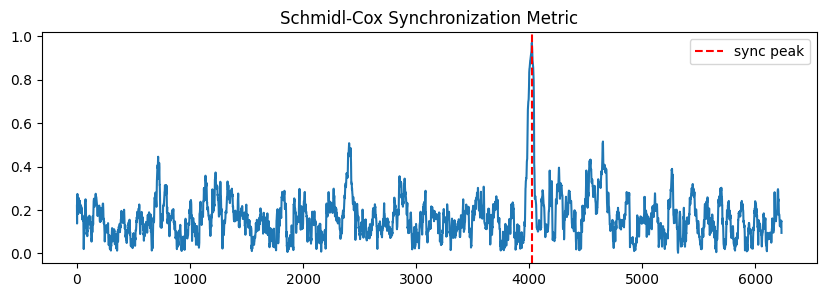

In [232]:

Tper = Nsc // 2

wins  = sliding_window_view(r_bb, 2 * Tper)
gamma = np.sum(wins[:, :Tper] * np.conj(wins[:, Tper:]), axis=1)
phi1  = np.sum(np.abs(wins[:, :Tper])**2, axis=1)
phi2  = np.sum(np.abs(wins[:, Tper:])**2, axis=1)
mu    = np.abs(gamma) / np.sqrt(phi1 * phi2 + 1e-10)

peak = int(np.argmax(mu))
print(f"Sync peak at OFDM data sample {peak}")

plt.figure(figsize=(10, 3))
plt.plot(mu)
plt.axvline(peak, color="r", ls="--", label="sync peak")
plt.title("Schmidl-Cox Synchronization Metric")
plt.grid()
plt.legend()
plt.show()


## FFT

In [ ]:
from scipy.signal import savgol_filter


def estimate_channel(X_pilot, X_length):
    """Combine pilot and length symbols into one frequency-domain channel estimate."""
    known_idx = np.arange(15, Nsc)
    H_from_length = X_length[known_idx] / (1 + 1j)

    even_idx = np.arange(0, Nsc, 2)
    H_from_pilot = X_pilot[even_idx] / (2 * get_P())

    H = np.empty(Nsc, dtype=complex)
    for k in range(Nsc):
        if k in known_idx and k in even_idx:
            j_len = np.where(known_idx == k)[0][0]
            j_pil = np.where(even_idx == k)[0][0]
            H[k] = 0.5 * (H_from_length[j_len] + H_from_pilot[j_pil])
        elif k in known_idx:
            j_len = np.where(known_idx == k)[0][0]
            H[k] = H_from_length[j_len]
        elif k in even_idx:
            j_pil = np.where(even_idx == k)[0][0]
            H[k] = H_from_pilot[j_pil]
        else:
            H[k] = 0

    for k in range(1, 15, 2):
        H[k] = 0.5 * (H[k - 1] + H[k + 1])

    return savgol_filter(H.real, 7, 3) + 1j * savgol_filter(H.imag, 7, 3)


def try_decode(t0, g2_poly, search_length=None):
    trellis = Trellis(memory=np.array([5]), g_matrix=np.array([[0o77, g2_poly]]))
    if t0 < 0 or len(r_bb) - t0 < 3 * (Nsc + Ncp):
        return None

    n_sym = (len(r_bb) - t0) // (Nsc + Ncp)
    blocks = r_bb[t0 : t0 + n_sym * (Nsc + Ncp)].reshape(n_sym, Nsc + Ncp)
    X = np.fft.fft(blocks[:, Ncp:], axis=1)

    H_full = estimate_channel(X[0], X[1])

    X_len_eq = X[1, :15] / H_full[:15]
    bits_len = np.empty(30, dtype=int)
    bits_len[0::2] = (X_len_eq.real < 0).astype(int)
    bits_len[1::2] = (X_len_eq.imag < 0).astype(int)
    dec_len = viterbi_decode(bits_len.astype(float), trellis, tb_depth=15, decoding_type='hard').astype(int)
    l_m_decoded = int(''.join(dec_len[:10].astype(str)), 2)

    candidates = [l_m_decoded] if search_length is None else search_length
    best_local = None

    for l_m in candidates:
        if l_m < 1 or l_m > 400:
            continue

        n_data = int(np.ceil((7 * l_m + 5) / Nsc))
        if n_sym < 2 + n_data:
            continue

        X_data = X[2 : 2 + n_data] / H_full
        bits_data = np.empty(X_data.size * 2, dtype=int)
        bits_data[0::2] = (X_data.real < 0).ravel().astype(int)
        bits_data[1::2] = (X_data.imag < 0).ravel().astype(int)
        needed = 14 * l_m + 10

        dec = viterbi_decode(bits_data[:needed].astype(float), trellis, decoding_type='hard').astype(int)
        msg_bits = dec[:7 * l_m]
        chars = []
        for i in range(l_m):
            b7 = msg_bits[7 * i : 7 * i + 7]
            if len(b7) == 7:
                chars.append(chr(int(''.join(b7.astype(str)), 2)))
        msg = ''.join(chars)

        printable = sum((32 <= ord(c) <= 126) or c in '\n\r\t' for c in msg)
        letters = sum(c.isalpha() or c == ' ' for c in msg)
        score = (printable + letters) / max(1, 2 * len(msg))

        candidate = {
            't0': t0,
            'l_m': l_m,
            'l_m_dec': l_m_decoded,
            'msg': msg,
            'score': score,
            'H': H_full,
            'X': X,
            'X_eq': X_data,
            'g2': g2_poly,
        }
        if best_local is None or score > best_local['score']:
            best_local = candidate

    return best_local


best_single = None
for g2 in (0o45, 0o51):
    for offset in range(-Ncp - 5, 5):
        t0 = peak + offset
        res = try_decode(t0, g2)
        if res is None:
            continue
        if best_single is None or res['score'] > best_single['score']:
            best_single = res

print(f"Best single decode: g2=0o{best_single['g2']:o}, t0={best_single['t0']}, "
      f"l_m(raw)={best_single['l_m_dec']}, l_m={best_single['l_m']}, score={best_single['score']:.3f}")
print(best_single['msg'])
print()

best_search = None
for g2 in (0o45, 0o51):
    for offset in range(-Ncp - 5, 5):
        t0 = peak + offset
        res = try_decode(t0, g2, search_length=range(50, 200))
        if res is None:
            continue
        if best_search is None or res['score'] > best_search['score']:
            best_search = res

print(f"Best exhaustive decode: g2=0o{best_search['g2']:o}, t0={best_search['t0']}, "
      f"l_m(raw)={best_search['l_m_dec']}, l_m={best_search['l_m']}, score={best_search['score']:.3f}")
print(best_search['msg'])

best = best_search if best_search['score'] >= best_single['score'] else best_single
X = best['X']
H_full = best['H']
X_eq = best['X_eq']
l_m = best['l_m']
message = best['msg']



Best single decode: g2=0o51, t0=4002, l_m(raw)=104, l_m=104, score=0.841
Any linear combination of Gaussian random variaales is again 9@GanB7	an randkmB*,HxVC{~  NC     <H



## Channel Estimation, Pilot Removal and Calibration

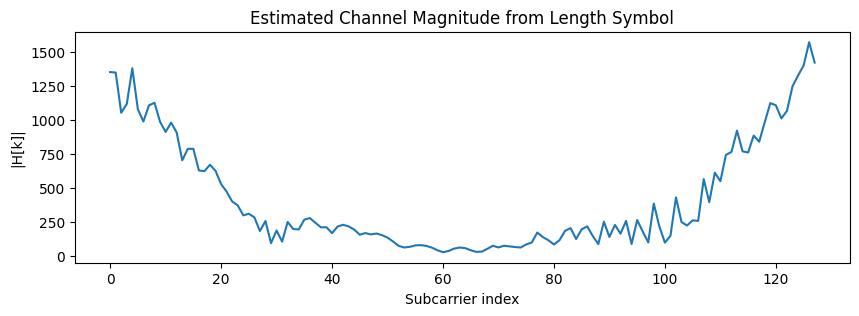

In [ ]:
plt.figure(figsize=(10, 3))
plt.plot(np.abs(H_full))
plt.title("Estimated Channel Magnitude (Pilot + Length Symbol)")
plt.xlabel("Subcarrier index")
plt.ylabel("|H[k]|")
plt.grid()
plt.show()



## Pilot removal and equalization

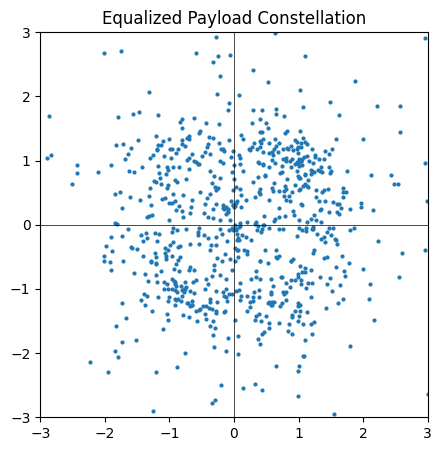

In [ ]:

plt.figure(figsize=(5, 5))
plt.scatter(X_eq.real.flatten(), X_eq.imag.flatten(), s=4)
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.axhline(0, color="k", lw=0.5)
plt.axvline(0, color="k", lw=0.5)
plt.title("Equalized Payload Constellation")
plt.grid()
plt.show()


## QPSK

In [ ]:

# Decoding is handled in the previous cell so that timing, channel estimation,
# and message-length search are evaluated together.


## Decoding and ASCII

In [ ]:

print(f"Message length: {l_m} characters")
print(message)


Message length: 104 characters
Any linear combination of G`I9an random wS4gvbhO is agaj	P9B(
B?)an rando=B _$31E.  LdM cUjt{]_r
